# Logistics Delivery Prediction


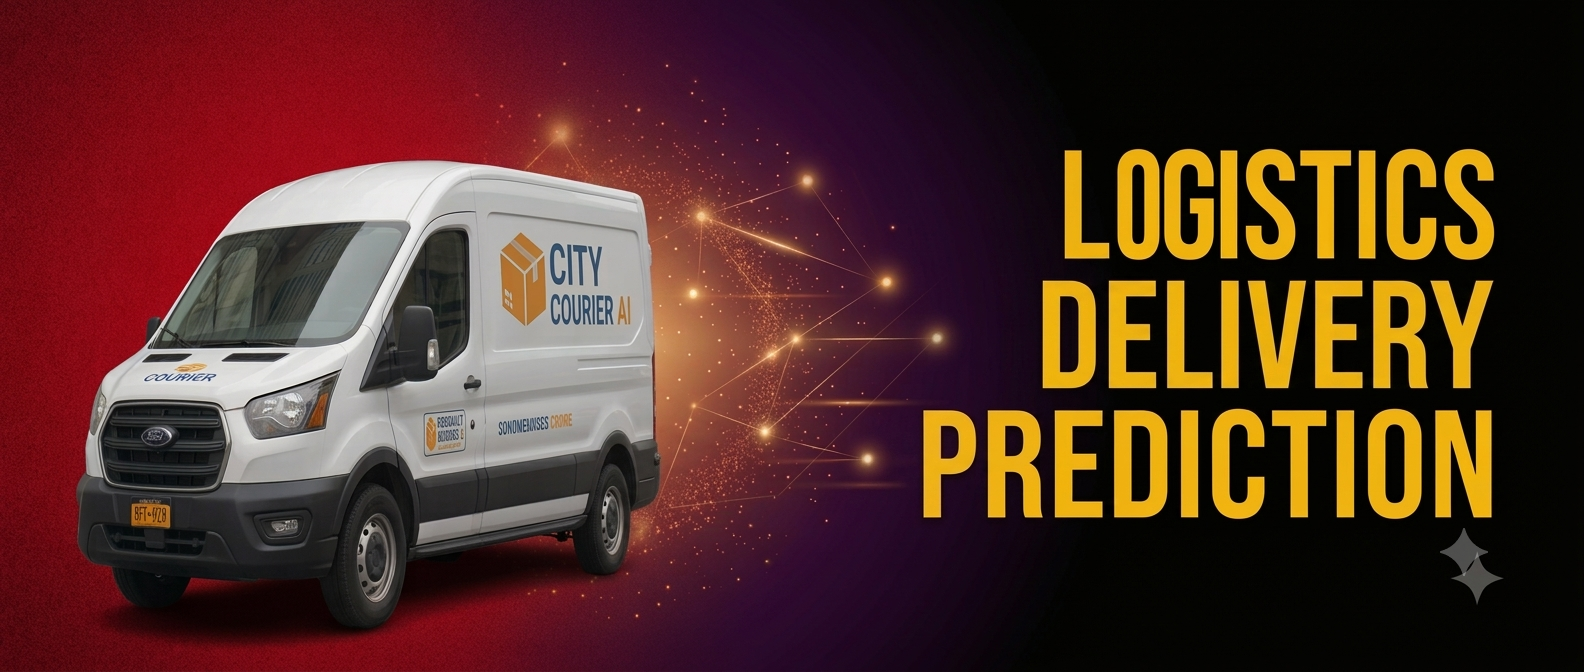

# Problem Statement

The logistics and delivery industry handles a large number of shipments every day, and delivery delays can negatively affect customer satisfaction, operational efficiency, and business performance. Therefore, there is a need for a machine learning system that can predict whether a delivery will be completed on time or delayed.

This project aims to develop a classification model that predicts the delivery status as either **Delivered** or **Delayed** using factors such as delivery partner, package type, vehicle type, delivery mode, region, weather condition, distance, package weight, and delivery cost.


# Objective

The main objective of this project is to build and evaluate machine learning classification models for predicting delivery status.

The specific objectives are:

1. To analyze the delivery logistics dataset and understand the factors associated with delivery status.
2. To perform exploratory data analysis to identify patterns in delivery-related data.
3. To preprocess categorical and numerical features for machine learning.
4. To train different classification models including Logistic Regression, Decision Tree, Random Forest, XGBoost, KNN, and SVM.
5. To evaluate the models using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.
6. To compare the performance of the different models and select a suitable model for delivery status prediction.


# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix , accuracy_score , precision_score , f1_score ,recall_score , ConfusionMatrixDisplay ,roc_auc_score

# Load Dataset

In [ ]:
df = pd.read_csv('Delivery_Logistics.csv')

# Data Overview

In [ ]:
df.shape

(25000, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   delivery_id        25000 non-null  float64
 1   delivery_partner   25000 non-null  object 
 2   package_type       25000 non-null  object 
 3   vehicle_type       25000 non-null  object 
 4   delivery_mode      25000 non-null  object 
 5   region             25000 non-null  object 
 6   weather_condition  25000 non-null  object 
 7   distance_km        25000 non-null  float64
 8   package_weight_kg  25000 non-null  float64
 9   delivery_status    25000 non-null  object 
 10  delivery_cost      25000 non-null  float64
dtypes: float64(4), object(7)
memory usage: 2.1+ MB


In [ ]:
df.describe()

,delivery_id,distance_km,package_weight_kg,delivery_cost
count,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,150.390436,25.145898,864.944579
std,7212.732314,86.409745,14.368663,435.712593
min,250.990000,3.600000,0.670000,95.667400
25%,6250.750000,75.900000,12.680000,490.800000
50%,12500.500000,151.000000,25.145000,867.535000
75%,18750.250000,224.900000,37.660000,1237.910000
max,24750.010000,297.100000,49.520000,1632.720600


In [ ]:
df.isnull().sum()

,0
delivery_id,0
delivery_partner,0
package_type,0
vehicle_type,0
delivery_mode,0
region,0
weather_condition,0
distance_km,0
package_weight_kg,0
delivery_status,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head(5)

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_status,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,Delivered,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,Delivered,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,Delivered,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,Delivered,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,Delivered,1394.5600


# Exploratory Data Analysis

## Univariate Analysis

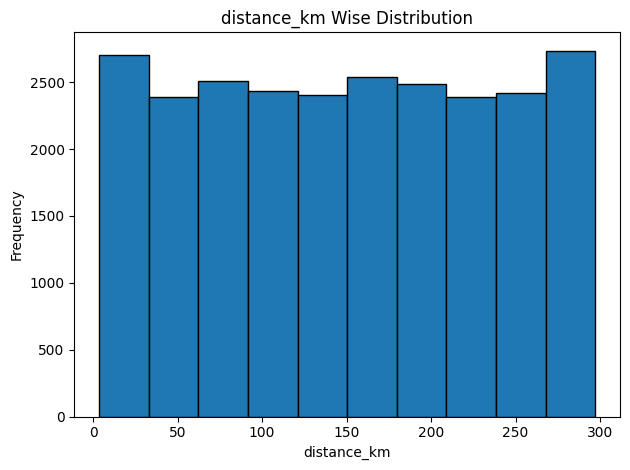

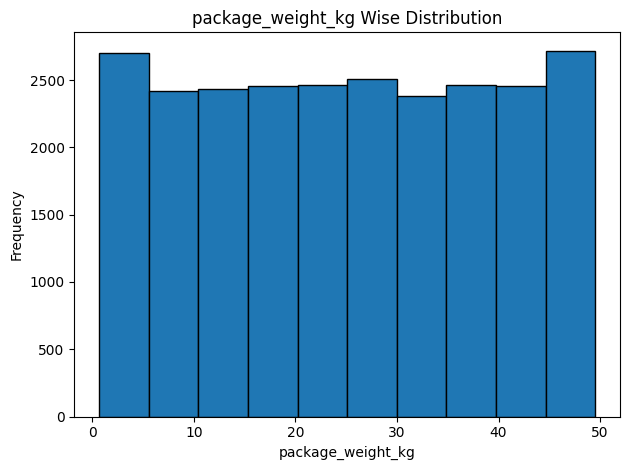

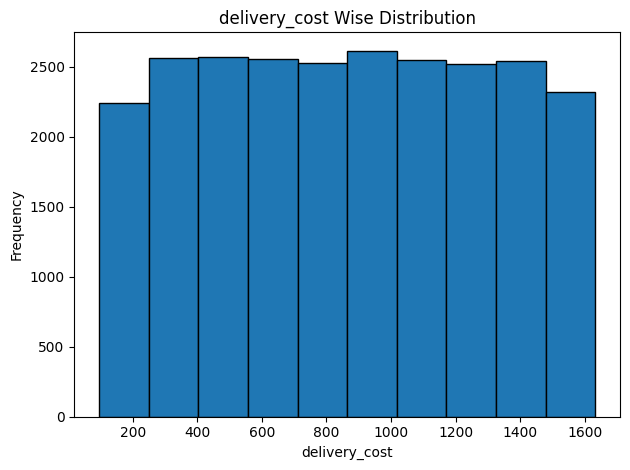

In [ ]:
num_cols = ['distance_km','package_weight_kg','delivery_cost']
for i in num_cols:
  plt.hist(df[i],edgecolor='black')
  plt.xlabel(i)
  plt.ylabel("Frequency")
  plt.title(i+" Wise Distribution")
  plt.tight_layout()
  plt.show()

## Bivariate Analysis

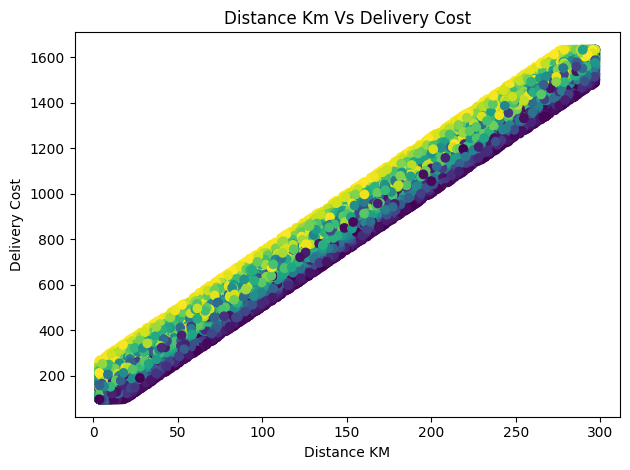

In [ ]:
plt.scatter(df['distance_km'],df['delivery_cost'],c=df['package_weight_kg'])
plt.xlabel("Distance KM")
plt.ylabel("Delivery Cost")
plt.title("Distance Km Vs Delivery Cost")
plt.tight_layout()
plt.show()

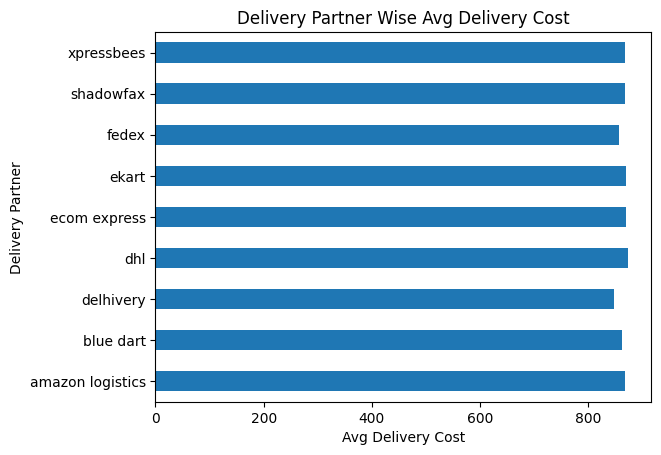

In [ ]:
delivery_partner_wise_delivery_cost = df.groupby('delivery_partner')['delivery_cost'].mean()
delivery_partner_wise_delivery_cost.plot(kind='barh',xlabel="Avg Delivery Cost",ylabel="Delivery Partner",title='Delivery Partner Wise Avg Delivery Cost')
plt.show()

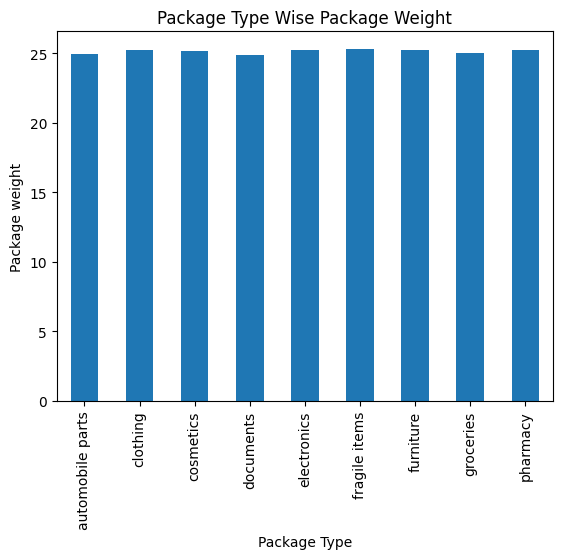

In [ ]:
package_type_wise_package_weight = df.groupby('package_type')['package_weight_kg'].mean()
package_type_wise_package_weight.plot(kind='bar',xlabel='Package Type',ylabel="Package weight",title="Package Type Wise Package Weight")
plt.show()

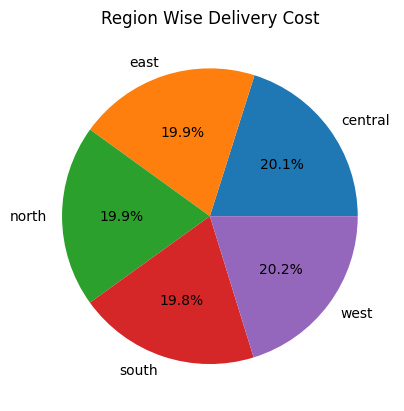

In [ ]:
region_wise_delivery_cost = df.groupby('region')['delivery_cost'].mean()
region_wise_delivery_cost.plot(kind='pie',ylabel='',autopct='%1.1f%%',title='Region Wise Delivery Cost')
plt.show()

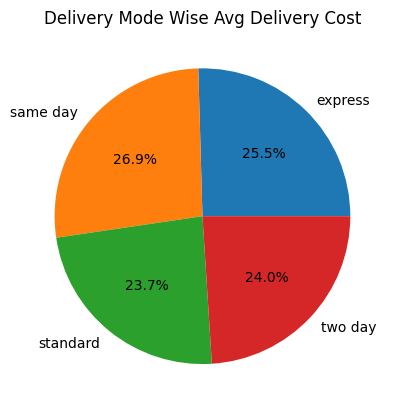

In [ ]:
deliver_mode_wise_delivery_cost = df.groupby('delivery_mode')['delivery_cost'].mean()
deliver_mode_wise_delivery_cost.plot(kind='pie',ylabel="",autopct='%1.1f%%',title="Delivery Mode Wise Avg Delivery Cost")
plt.show()

# Data Preprocessing

In [ ]:
df.columns

Index(['delivery_id', 'delivery_partner', 'package_type', 'vehicle_type',
       'delivery_mode', 'region', 'weather_condition', 'distance_km',
       'package_weight_kg', 'delivery_status', 'delivery_cost'],
      dtype='object')

In [ ]:
df = pd.get_dummies(df,columns=['delivery_partner','package_type','vehicle_type','delivery_mode','region','weather_condition'],dtype=int)

In [ ]:
df = df.drop('delivery_id',axis=1)

In [ ]:
df.columns

Index(['distance_km', 'package_weight_kg', 'delivery_status', 'delivery_cost',
       'delivery_partner_amazon logistics', 'delivery_partner_blue dart',
       'delivery_partner_delhivery', 'delivery_partner_dhl',
       'delivery_partner_ecom express', 'delivery_partner_ekart',
       'delivery_partner_fedex', 'delivery_partner_shadowfax',
       'delivery_partner_xpressbees', 'package_type_automobile parts',
       'package_type_clothing', 'package_type_cosmetics',
       'package_type_documents', 'package_type_electronics',
       'package_type_fragile items', 'package_type_furniture',
       'package_type_groceries', 'package_type_pharmacy', 'vehicle_type_bike',
       'vehicle_type_ev bike', 'vehicle_type_ev van', 'vehicle_type_scooter',
       'vehicle_type_truck', 'vehicle_type_van', 'delivery_mode_express',
       'delivery_mode_same day', 'delivery_mode_standard',
       'delivery_mode_two day', 'region_central', 'region_east',
       'region_north', 'region_south', 'region_we

In [ ]:
df['delivery_status'] = df['delivery_status'].map(
    {
        "Delivered":0,
        "Delayed":1
    }
)

In [ ]:
x = df.drop('delivery_status',axis=1)
y = df['delivery_status']

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.20 , random_state=42)

# Logistic Regression Model

In [ ]:
model_lr = LogisticRegression(max_iter=5000,random_state=42)

In [ ]:
model_lr.fit(x_train , y_train)

LogisticRegression(max_iter=5000, random_state=42)

In [ ]:
y_pred = model_lr.predict(x_test)

In [ ]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[3430,  247],
       [ 233, 1090]])

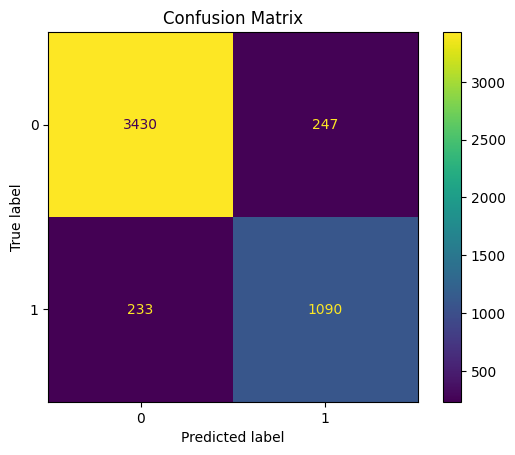

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.title("Confusion Matrix")
plt.show()

## Model 1 Evaluation

In [ ]:
accuracy_lr = accuracy_score(y_test,y_pred)
precision_lr = precision_score(y_test,y_pred)
recall_lr = recall_score(y_test,y_pred)
f1_lr = f1_score(y_test,y_pred)

y_pred_prob = model_lr.predict_proba(x_test)[:,1]
roc_auc_lr = roc_auc_score(y_test,y_pred_prob)

evaluation_lr = pd.DataFrame({
    "Accuracy":[accuracy_lr],
    "Precision":[precision_lr],
    "Recall":[recall_lr],
    "F1":[f1_lr],
    "ROC_AUC_SCORE":[roc_auc_lr]
})
evaluation_lr

,Accuracy,Precision,Recall,F1,ROC_AUC_SCORE
0,0.904,0.815258,0.823885,0.819549,0.964328


# DecisionTreeClassifier Model

In [ ]:
model_dr = DecisionTreeClassifier(max_depth=3,random_state=42)

In [ ]:
model_dr.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
y_pred_dr = model_dr.predict(x_test)

In [ ]:
cm = confusion_matrix(y_test,y_pred_dr)
cm

array([[3162,  515],
       [ 108, 1215]])

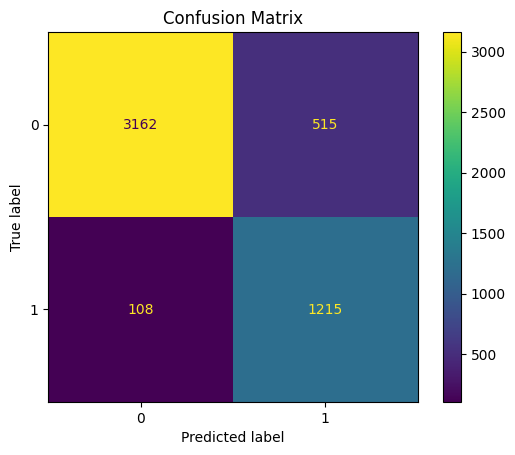

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test , y_pred_dr)
plt.title("Confusion Matrix")
plt.show()

## Model 2 Evaluation

In [117]:
accuracy_dr = accuracy_score(y_test , y_pred_dr)
precision_dr = precision_score(y_test , y_pred_dr)
recall_dr = recall_score(y_test , y_pred_dr)
f1_dr = f1_score(y_test , y_pred_dr)

y_pred_prob_dr = model_dr.predict_proba(x_test)[:,1]
roc_auc_dr = roc_auc_score(y_test,y_pred_prob_dr)

evaluation_dr = pd.DataFrame({
    "Accuracy":[accuracy_dr],
    "Precision":[precision_dr],
    "Recall":[recall_dr],
    "F1":[f1_dr],
    "ROC_AUC":[roc_auc_dr]
})
evaluation_dr

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.8754,0.702312,0.918367,0.795938,0.936981


# RandomForestClassifier Model

In [ ]:
model_rf = RandomForestClassifier(n_estimators=1000,max_depth=5,random_state=42)

In [ ]:
model_rf.fit(x_train,y_train)

RandomForestClassifier(max_depth=5, n_estimators=1000, random_state=42)

In [ ]:
y_pred_rf = model_rf.predict(x_test)

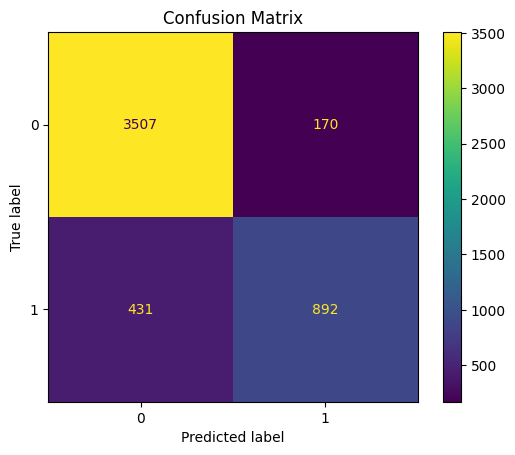

In [ ]:
cm = confusion_matrix(y_test,y_pred_rf)
ConfusionMatrixDisplay.from_predictions(y_test , y_pred_rf)
plt.title("Confusion Matrix")
plt.show()

## Model 3 Evaluation

In [ ]:
accuracy_rf = accuracy_score(y_test , y_pred_rf)
precision_rf = precision_score(y_test , y_pred_rf)
recall_rf = recall_score(y_test , y_pred_rf)
f1_rf = f1_score(y_test , y_pred_rf)

y_pred_prob = model_rf.predict_proba(x_test)[:,1]
roc_auc_rf = roc_auc_score(y_test,y_pred_prob)

evaluation_rf = pd.DataFrame({
    "Accuracy":[accuracy_rf],
    "Precision":[precision_rf],
    "Recall":[recall_rf],
    "F1":[f1_rf],
    "ROC_AUC":[roc_auc_rf]
})
evaluation_rf

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.8798,0.839925,0.674225,0.748008,0.959807


# XGClassifier Model

In [ ]:
model_xg = XGBClassifier(n_estimators=100, learning_rate=0.1,max_depth=3,random_state=42)

In [ ]:
model_xg.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xg = model_xg.predict(x_test)

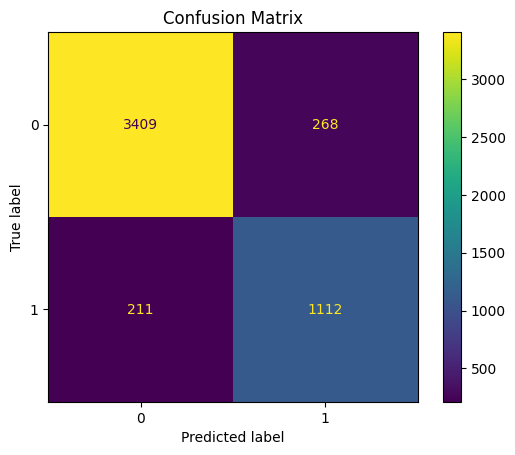

In [ ]:
cm = confusion_matrix(y_test,y_pred_xg)
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_xg)
plt.title("Confusion Matrix")
plt.show()

## Model 4 Evaluation

In [ ]:
accuracy_xg = accuracy_score(y_test, y_pred_xg)
precision_xg = precision_score(y_test, y_pred_xg)
recall_xg = recall_score(y_test, y_pred_xg)
f1_xg = f1_score(y_test, y_pred_xg)

y_pred_prob_xg = model_xg.predict_proba(x_test)[:, 1]
roc_auc_xg = roc_auc_score(y_test, y_pred_prob_xg)

evaluation_xg = pd.DataFrame({
    "Accuracy": [accuracy_xg],
    "Precision": [precision_xg],
    "Recall": [recall_xg],
    "F1": [f1_xg],
    "ROC_AUC": [roc_auc_xg]
})

evaluation_xg

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.9042,0.805797,0.840514,0.822789,0.969216


# KNeighbors Model

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
model_knn = KNeighborsClassifier(n_neighbors=3)

In [ ]:
model_knn.fit(x_train_scaled,y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred_knn = model_knn.predict(x_test_scaled)

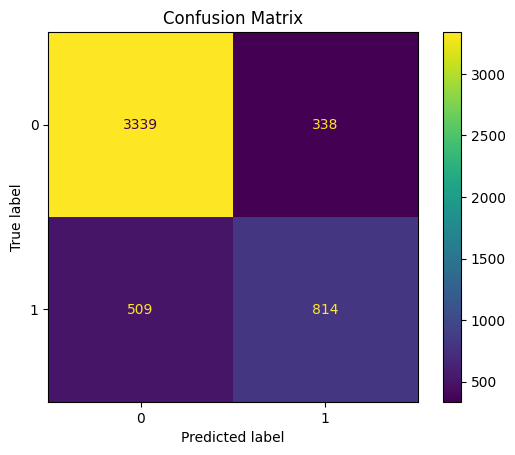

In [118]:
cm = confusion_matrix(y_test,y_pred_knn)
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_knn)
plt.title("Confusion Matrix")
plt.show()

## Model 5 Evaluation

In [ ]:
accuracy_knn = accuracy_score(y_test,y_pred_knn)
precision_knn = precision_score(y_test,y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test,y_pred_knn)

y_pred_prob_knn = model_knn.predict_proba(x_test_scaled)[:,1]
roc_auc_knn = roc_auc_score(y_test,y_pred_prob_knn)

evaluation_knn = pd.DataFrame({
    "Accuracy":[accuracy_knn],
    "Precision":[precision_knn],
    "Recall":[recall_knn],
    "F1":[f1_knn],
    "ROC_AUC":[roc_auc_knn]
})
evaluation_knn

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.8306,0.706597,0.615268,0.657778,0.850038


# SVM Model

In [ ]:
model_svc = SVC(kernel="linear",C=10,gamma='scale')

In [ ]:
model_svc.fit(x_train_scaled,y_train)

SVC(C=10, kernel='linear')

In [ ]:
y_pred_svc = model_svc.predict(x_test_scaled)

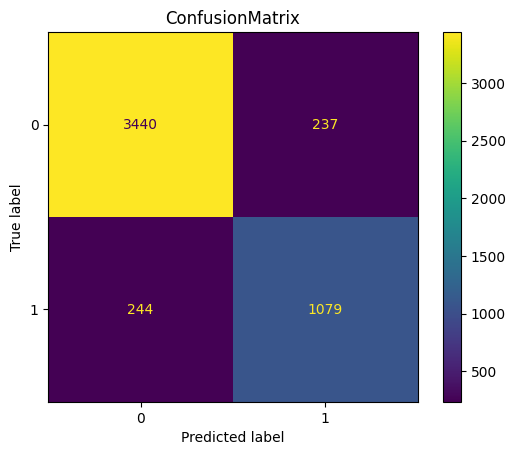

In [ ]:
cm_svc = confusion_matrix(y_test,y_pred_svc)
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_svc)
plt.title("ConfusionMatrix")
plt.show()

## Model 6 Evaluation

In [ ]:
accuracy_svc = accuracy_score(y_test,y_pred_svc)
precision_svc = precision_score(y_test,y_pred_svc)
recall_svc = recall_score(y_test,y_pred_svc)
f1_svc = f1_score(y_test,y_pred_svc)

y_score = model_svc.decision_function(x_test_scaled)
roc_auc_svc = roc_auc_score(y_test,y_score)
evaluation_svc = pd.DataFrame({
    "Accuracy":[accuracy_svc],
    "Precision":[precision_svc],
    "Recall":[recall_svc],
    "F1":[f1_svc],
    "ROC_AUC":[roc_auc_svc]
})
evaluation_svc

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.9038,0.819909,0.815571,0.817734,0.963586


# All Models Evaluation

In [ ]:
comparision = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "KNN",
        "SVM"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_dr,
        accuracy_rf,
        accuracy_xg,
        accuracy_knn,
        accuracy_svc
    ],

    "Precision": [
        precision_lr,
        precision_dr,
        precision_rf,
        precision_xg,
        precision_knn,
        precision_svc
    ],

    "Recall": [
        recall_lr,
        recall_dr,
        recall_rf,
        recall_xg,
        recall_knn,
        recall_svc
    ],

    "F1 Score": [
        f1_lr,
        f1_dr,
        f1_rf,
        f1_xg,
        f1_knn,
        f1_svc
    ],

    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_dr,
        roc_auc_rf,
        roc_auc_xg,
        roc_auc_knn,
        roc_auc_svc
    ]
})
comparision

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9040,0.815258,0.823885,0.819549,0.964328
1,Decision Tree,0.9040,0.815258,0.823885,0.819549,0.936981
2,Random Forest,0.8798,0.839925,0.674225,0.748008,0.959807
3,XGBoost,0.9042,0.805797,0.840514,0.822789,0.969216
4,KNN,0.8306,0.706597,0.615268,0.657778,0.850038
5,SVM,0.9038,0.819909,0.815571,0.817734,0.963586


# Prediction

In [ ]:
sample_data = [[
    12.5,    # distance_km
    2.3,     # package_weight_kg
    180,     # delivery_cost

    # delivery_partner
    0,  # amazon logistics
    0,  # blue dart
    1,  # delhivery
    0,  # dhl
    0,  # ecom express
    0,  # ekart
    0,  # fedex
    0,  # shadowfax
    0,  # xpressbees

    # package_type
    0,  # automobile parts
    1,  # clothing
    0,  # cosmetics
    0,  # documents
    0,  # electronics
    0,  # fragile items
    0,  # furniture
    0,  # groceries
    0,  # pharmacy

    # vehicle_type
    0,  # bike
    1,  # ev bike
    0,  # ev van
    0,  # scooter
    0,  # truck
    0,  # van

    # delivery_mode
    1,  # express
    0,  # same day
    0,  # standard
    0,  # two day

    # region
    0,  # central
    0,  # east
    0,  # north
    1,  # south
    0,  # west

    # weather_condition
    1,  # clear
    0,  # cold
    0,  # foggy
    0,  # hot
    0,  # rainy
    0   # stormy
]]

sample_df = pd.DataFrame(sample_data, columns=x.columns)

prediction = model_xg.predict(sample_df)

print(prediction)

[0]


# Conclusion

The Delivery Logistics Prediction project successfully developed a machine learning model to predict whether a delivery will be **Delivered or Delayed**. After preprocessing the data and comparing multiple classification algorithms, **XGBoost was selected as the final model** based on its overall performance.

The XGBoost model achieved an **accuracy of 90.42%**, with a **precision of 80.58%**, **recall of 84.05%**, **F1-score of 82.28%**, and **ROC-AUC of 0.9692**. These results show that the model can effectively classify delivery statuses and identify deliveries that may be delayed.

Overall, the XGBoost model provides a reliable machine learning approach for delivery status prediction and can help logistics organizations improve delivery planning and operational efficiency.
